This piece of code performs training of the NN against the PDF data. Prepared PDF data is required to run this code. The labels for data are taken from the names of each dataset, so better be prepared for labelling. In principle, this code can process both calculated PDF data, as well as experimental PDF data. The latter may require additinal processing which is performed by 'preparePDFexp.ipynb'. Calculated data may be prepared from a batch of xyz files by 'preparePDF.ipynb'

In [17]:
import numpy as np
np.random.seed(1337) 
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, Normalizer
from keras.models import Sequential
from keras.layers import Dense, Conv1D, BatchNormalization, MaxPooling1D, LeakyReLU, Flatten, Dropout
from keras_self_attention import SeqSelfAttention
from keras.utils import custom_object_scope
from keras.callbacks import History, ModelCheckpoint, EarlyStopping
from keras import backend as K
from keras import metrics, regularizers
from keras.optimizers import Adam, Adagrad, Adadelta, RMSprop
from keras_tuner import RandomSearch, Hyperband
from keras_tuner.engine.hyperparameters import HyperParameters
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score
import keras.regularizers
import keras
import glob
import os
import itertools
import fnmatch

In [2]:
os.chdir('/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/all_data/cifs/')

In [3]:
files_calc = glob.glob('*.dat')
files_exp = glob.glob('*processed.gr')

Counts of clusters by their nuclearity: {'1': 74, '2': 170, '3': 6, '4': 107, '5': 7, '6': 32, '7': 20, '8': 17, '9': 30}
Sliced cluster catalogue: ['4_BALMIM.dat', '4_WOSRUT.dat', '2_HOGQEB.dat', '2_JUXDIP.dat', '2_FACAPR01.dat', '9_UZICEM.dat', '4_KOMBIZ.dat', '6_IFESAP.dat', '1_HEKQAP.dat', '5_MACTES.dat', '8_ZIJSIW.dat', '4_NORVUN.dat', '8_WIGYEQ.dat', '4_RUJGUA.dat', '2_LAWGOH.dat', '7_LICZUU.dat', '4_UXUNUY.dat', '4_EGEYOF.dat', '4_XIVZIM.dat', '4_ODICUZ01.dat', '1_BUTKEH.dat', '6_GOMTOR.dat', '6_HUHZIV.dat', '4_KOMBOF01.dat', '2_DESZAD.dat', '5_MACTES01.dat', '4_UJIPEK.dat', '4_POQHAG.dat', '1_HOQCUM.dat', '2_WEFCUH.dat', '4_ZAFWUB.dat', '1_ENOVUA.dat', '4_XOYQOS.dat', '2_PILXOY.dat', '4_MAGFOR.dat', '2_HOQCAS.dat', '1_POHMOQ.dat', '2_ICOWON.dat', '7_XOSZOW.dat', '9_LOSVOG.dat', '4_WIVBOS.dat', '2_HOLACT.dat', '7_LICZOO.dat', '7_ILESUN.dat', '2_TACERB.dat', '2_GETPEB.dat', '7_HUPRUH.dat', '1_PIQMUZ.dat', '1_TOJJIN.dat', '8_ZIJTOD.dat', '2_SOMJUB.dat', '4_BALNAF.dat', '2_MIHPOI.d

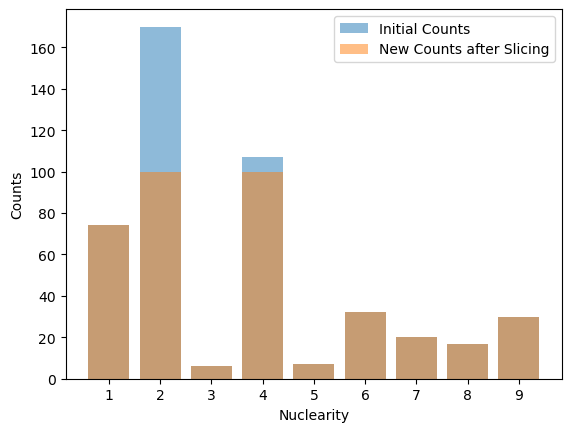

In [6]:
from collections import defaultdict
import matplotlib.pyplot as plt

def analyze_filenames(filenames):
    # Count how many filenames start with each digit from 1 to 9
    counts = defaultdict(int)
    for filename in filenames:
        if filename[0].isdigit() and filename[0] != '0':
            counts[filename[0]] += 1       
    return counts

def create_output_array(filenames, selected_counts):
    # Create the output array based on the selected counts for each digit
    output_array = []
    current_counts = defaultdict(int)
    for filename in filenames:
        digit = filename[0]
        if digit in selected_counts and current_counts[digit] < selected_counts[digit]:
            output_array.append(filename)
            current_counts[digit] += 1
            
    return output_array

files_calc.extend(files_exp)
counts = analyze_filenames(files_calc)
sorted_counts = {str(digit): counts.get(str(digit), 0) for digit in range(1, 10)}
print("Counts of clusters by their nuclearity:", sorted_counts)

selected_counts = {
    '1': 100, # Specify how many filenames starting with '1' you want
    '2': 100, # Specify how many filenames starting with '2' you want
    '3': 100,  # Specify how many filenames starting with '3' you want
    '4': 100,  # Specify how many filenames starting with '3' you want
    '5': 100,  # Specify how many filenames starting with '3' you want
    '6': 100,  # Specify how many filenames starting with '3' you want
    '7': 100,  # Specify how many filenames starting with '3' you want
    '8': 100,  # Specify how many filenames starting with '3' you want
    '9': 100  # Specify how many filenames starting with '3' you want
}

files_calc_sliced = create_output_array(files_calc, selected_counts)
print("Sliced cluster catalogue:", files_calc_sliced)

counts = analyze_filenames(files_calc_sliced)
sorted_counts2 = {str(digit): counts.get(str(digit), 0) for digit in range(1, 10)}
print("Counts of clusters by their nuclearity:", sorted_counts2)

digits = list(sorted_counts.keys())
initial_values = list(sorted_counts.values())
new_values = list(sorted_counts2.values()) # Use sorted counts for the new values

total_elements_in_sliced = len(files_calc_sliced)
print("Total number of elements in the sliced cluster catalogue:", total_elements_in_sliced)

plt.bar(digits, initial_values, alpha=0.5, label='Initial Counts')
plt.bar(digits, new_values, alpha=0.5, label='New Counts after Slicing')
plt.xlabel('Nuclearity')
plt.ylabel('Counts')
plt.legend()
plt.show()


In [8]:
raw_data_points = []

with open('labels.txt', 'w') as labels:
    for f in files_calc:
        if 'processed' in f:
            # For files containing 'processed' in their names (second type)
            df = pd.read_csv(f, usecols=[1], skiprows=1, header=None, delim_whitespace=True, skipfooter=1, engine='python')
        else:
            # For files not containing 'processed' in their names (first type)
            df = pd.read_csv(f, usecols=[1], skiprows=201, header=None, delim_whitespace=True, skipfooter=800, engine='python')

        raw_data_points.append(df.values.ravel())
        
        if f[0] == 'p':
            labels.write('10')
            labels.write('\n')
        else:    
            labels.write(f[0])
            labels.write('\n')

raw_data_points = np.array(raw_data_points)

# Load the labels
labels = pd.read_csv("labels.txt", header=None)
labels = labels.values.ravel()  # convert the labels to a 1D array

10


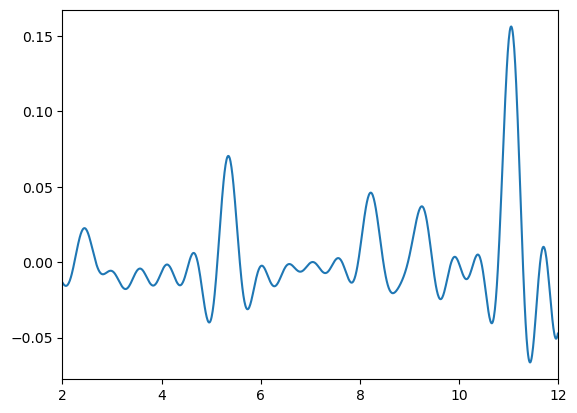

In [10]:
%matplotlib inline
import matplotlib.pyplot as plt
# Preprocessing
#scaler = MinMaxScaler()
#scaler = StandardScaler()
#scaler =MaxAbsScaler()
#data_points = scaler.fit_transform(data_points)
normalize = Normalizer()
data_points = normalize.fit_transform(raw_data_points)
fig, ax = plt.subplots()
ax.set_xlim(2,12)
ax.plot(np.arange(len(data_points[77,:]))/100+2, data_points[77,:])
print(labels[77])


In [13]:
# Let's do some hyperparameter tuning

def build_model(hp):
    model = Sequential()
    model.add(Conv1D(filters=hp.Choice('filters1', [8, 16, 32]),
                     kernel_size=hp.Choice('kernel_size1', [64, 128, 256]),
                     activation='relu', input_shape=(1000, 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(hp.Float('dropout', 0.1, 0.9, step=0.1)))
    model.add(Conv1D(filters=hp.Choice('filters2', [32, 64, 128]),
                     kernel_size=hp.Choice('kernel_size2', [16, 32, 64]),
                     activation='relu'))
    model.add(Dropout(hp.Float('dropout', 0.1, 0.9, step=0.1)))
    model.add(SeqSelfAttention(attention_width=16, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL))
    model.add(Flatten())
    model.add(Dense(units=hp.Choice('dense_units', [64, 128, 256]), activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)))
    model.add(Dropout(hp.Float('dropout', 0.1, 0.9, step=0.1)))
    model.add(Dense(units=11, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01)))
    optimizer = Adam(learning_rate=hp.Float('learning_rate', 1e-4, 1e-1, sampling='log'))
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [14]:
X_train, X_val, y_train, y_val = train_test_split(data_points, labels, test_size=0.2, random_state=42)
tuner = Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=200,
    factor=3,
    project_name='hyperband_2-12'
)

tuner.search(X_train, y_train, epochs=200, validation_data=(X_val, y_val), callbacks=[EarlyStopping(monitor='val_loss', patience=3)])
tuner.search_space_summary()
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print(best_hyperparameters.values)
best_model = tuner.get_best_models(num_models=1)[0]
best_model.save('tuned_csd_2-12.h5')

Trial 246 Complete [00h 00m 59s]
val_accuracy: 0.8142856955528259

Best val_accuracy So Far: 0.8500000238418579
Total elapsed time: 01h 04m 44s
INFO:tensorflow:Oracle triggered exit


Search space summary
Default search space size: 7
filters1 (Choice)
{'default': 8, 'conditions': [], 'values': [8, 16, 32], 'ordered': True}
kernel_size1 (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
dropout (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.9, 'step': 0.1, 'sampling': 'linear'}
filters2 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
kernel_size2 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
dense_units (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.1, 'step': None, 'sampling': 'log'}
{'filters1': 8, 'kernel_size1': 128, 'dropout': 0.30000000000000004, 'filters2': 64, 'kernel_size2': 64, 'dense_units': 64, 'learning_rate': 0.00023499675055028255, 'tuner/epochs': 67, 'tuner/initial_epoch': 23, 'tune

In [15]:
def create_model():
    # Tuning of the model

    model = Sequential()
    # Add the convolutional layers
    model.add(Conv1D(filters=8, kernel_size=128, activation='relu', input_shape=(1000, 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))
    model.add(Conv1D(filters=64, kernel_size=64, activation='relu'))
    model.add(SeqSelfAttention(attention_width=32, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL)) 

    # Flatten the output of the convolutional layers
    model.add(Flatten())

    # Add the fully connected layers
    model.add(Dense(units=64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))) # 128 
    model.add(Dropout(0.3))
    model.add(Dense(units=11, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01))) # 10 

    # Compile the model
    optimizer = Adam(learning_rate=0.00023)
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

In [18]:
num_folds = 10
num_epochs = 200
kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)
fold_num = 1  # to keep track of which fold you're on
all_fold_results = []  # list to store performance metrics for each fold

In [19]:
for train_index, val_index in kf.split(data_points):
    X_train, X_val = data_points[train_index], data_points[val_index]
    y_train, y_val = labels[train_index], labels[val_index]
    
    model = create_model()
    
    checkpoint_name = f"new_fold_{fold_num}_model.hdf5"
    checkpoint = ModelCheckpoint(checkpoint_name, monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)
    
    print(f'Training fold {fold_num}...')
    model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_val, y_val), callbacks=[checkpoint])
    
    # Load the best model saved by the checkpoint and evaluate
    with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
        load_model = keras.models.load_model(checkpoint_name)
        
    val_loss, val_acc = load_model.evaluate(X_val, y_val)
    print(f'Fold {fold_num} accuracy:', val_acc)
    
    all_fold_results.append(val_acc)
    
    fold_num += 1

# Print overall performance across all folds
print('All fold accuracies:', all_fold_results)
print('Mean accuracy:', np.mean(all_fold_results))
print('Standard deviation:', np.std(all_fold_results))

Training fold 1...
Epoch 1/200
20/20 [==============================] - ETA: 0s - loss: 2.9407 - accuracy: 0.4365
Epoch 1: val_accuracy improved from -inf to 0.55714, saving model to new_fold_1_model.hdf5
20/20 [==============================] - 3s 112ms/step - loss: 2.9407 - accuracy: 0.4365 - val_loss: 3.4370 - val_accuracy: 0.5571
Epoch 2/200
20/20 [==============================] - ETA: 0s - loss: 2.2114 - accuracy: 0.6016
Epoch 2: val_accuracy improved from 0.55714 to 0.65714, saving model to new_fold_1_model.hdf5
20/20 [==============================] - 2s 89ms/step - loss: 2.2114 - accuracy: 0.6016 - val_loss: 3.1533 - val_accuracy: 0.6571
Epoch 3/200
20/20 [==============================] - ETA: 0s - loss: 1.8637 - accuracy: 0.6905
Epoch 3: val_accuracy did not improve from 0.65714
20/20 [==============================] - 2s 80ms/step - loss: 1.8637 - accuracy: 0.6905 - val_loss: 2.9705 - val_accuracy: 0.6429
Epoch 4/200
20/20 [==============================] - ETA: 0s - loss: 

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data_points, labels, test_size=0.2, random_state=42)

with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    load_model = keras.models.load_model('/Users/dimitrygrebenyuk/Yandex.Disk.localized/Working/PDF/Refinements/PDF-Cluster-Prediction/th_clusters/ce_groups/tuned_sliced_сe_calc_2-12_retrain.h5')

load_model.evaluate(X_test, y_test)
y_pred_prob = load_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
confusion = confusion_matrix(y_test, y_pred)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)
precision = precision_score(y_test, y_pred, average=None)
print('Confusion matrix', confusion)
print('Recall score:', recall)
print('F1 score:', f1)
print('Precision score:', precision)

import matplotlib.pyplot as plt

def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot the confusion matrix
plot_confusion_matrix(confusion, classes = np.unique(y_test), title='Confusion matrix', normalize=False)
plt.show()